In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Mall Customer Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")

Display First  5 Rows

In [4]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Understand Dataset

Dataset Shape

In [5]:
df.shape

(200, 5)

Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Missing Values

In [7]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Preprocessing

Check Duplicates

In [9]:
df.duplicated().sum()

0

# Select Features

In [10]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

# Feature Scaling

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Find Optimal Number of Clusters (Elbow Method)

In [12]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

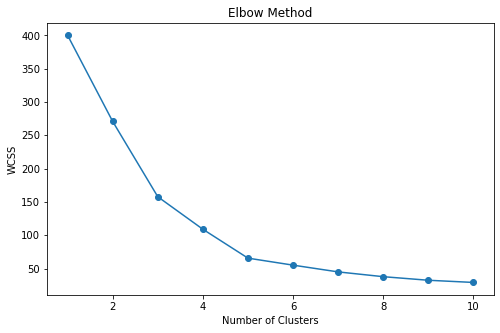

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Interpretation

Look for the bend/elbow point.

K = 5

Apply K-Means Clustering

In [15]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    X_scaled
)

# Visualize Clusters

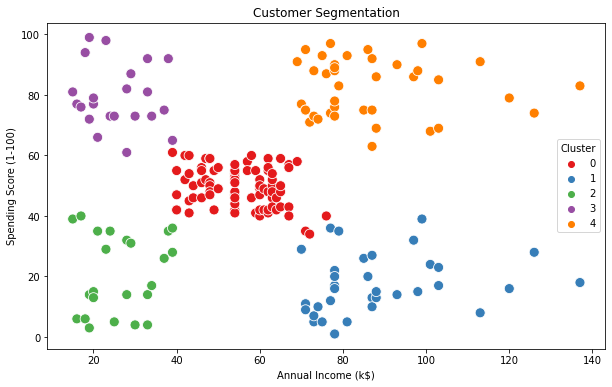

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(

x=df['Annual Income (k$)'],

y=df['Spending Score (1-100)'],

hue=df['Cluster'],

palette='Set1',

s=100
)

plt.title(
"Customer Segmentation"
)

plt.show()

# Plot Cluster Centers

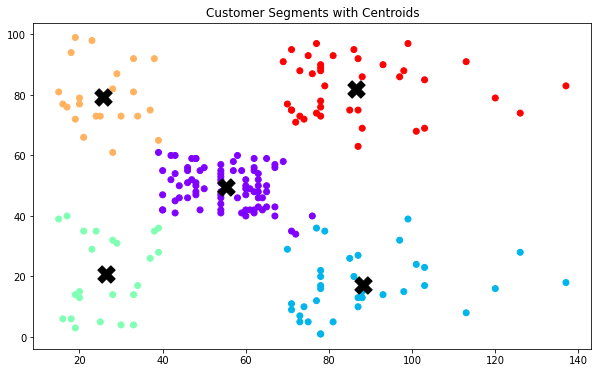

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(

df['Annual Income (k$)'],

df['Spending Score (1-100)'],

c=df['Cluster'],

cmap='rainbow'
)

centers = scaler.inverse_transform(
kmeans.cluster_centers_
)

plt.scatter(

centers[:,0],

centers[:,1],

s=300,

c='black',

marker='X'
)

plt.title(
"Customer Segments with Centroids"
)

plt.show()

 # Analyze Customer Segments

Count customers.

In [18]:
df['Cluster'].value_counts()

0    81
4    39
1    35
2    23
3    22
Name: Cluster, dtype: int64

View Each Segment

In [19]:
df.groupby('Cluster').mean()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,164.371429,41.114286,88.200000,17.114286
2,23.000000,45.217391,26.304348,20.913043
3,23.090909,25.272727,25.727273,79.363636
4,162.000000,32.692308,86.538462,82.128205


# Insights

# Cluster 0

Low Income + Low Spending

Budget customers.


# Cluster 1

High Income + High Spending

Premium customers.


# Cluster 2

High Income + Low Spending

Potential target customers.


# Cluster 3

Low Income + High Spending

Impulse buyers.


# Cluster 4

Medium customers.

# CONCLUSION

The customer segmentation analysis grouped mall customers into different behavioral segments using K-Means clustering.

Five clusters were identified based on annual income and spending score.

High-income high-spending customers were identified as premium customers, while high-income low-spending customers represent potential marketing targets.

The segmentation can help businesses improve marketing strategies and customer targeting.